### Data Loading

I will load the `fund_master` and `nav_history` datasets. These datasets will be crucial for calculating various financial metrics.

In [1]:
import pandas as pd

# Load 01_fund_master.csv
fund_master_url = 'http://github.com/neeraj-ch7/bluestock_mf_capstone/blob/main/data/raw/01_fund_master.csv?raw=true'
fund_master_df = pd.read_csv(fund_master_url)

# Load 02_nav_history.csv
nav_history_url = 'https://github.com/neeraj-ch7/bluestock_mf_capstone/blob/main/data/raw/02_nav_history.csv?raw=true'
nav_history_df = pd.read_csv(nav_history_url)

print("Fund Master DataFrame (first 5 rows):")
display(fund_master_df.head())

print("\nNAV History DataFrame (first 5 rows):")
display(nav_history_df.head())

Fund Master DataFrame (first 5 rows):


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02



NAV History DataFrame (first 5 rows):


,amfi_code,date,nav
0,119551,2022-01-03,54.3856
1,119551,2022-01-04,54.3474
2,119551,2022-01-05,54.6869
3,119551,2022-01-06,55.4550
4,119551,2022-01-07,55.3692


### Data Preprocessing and Daily Returns Calculation

To calculate daily returns, I'll first ensure the `date` column in `nav_history_df` is in datetime format and then sort the data by `amfi_code` and `date`. After that, I will group by `amfi_code` and calculate the daily percentage change of NAV.

In [2]:
# Convert 'date' column to datetime objects
nav_history_df['date'] = pd.to_datetime(nav_history_df['date'])

# Sort by amfi_code and date to ensure correct daily return calculation
nav_history_df = nav_history_df.sort_values(by=['amfi_code', 'date'])

# Calculate daily returns for each fund
# Group by 'amfi_code' and then use pct_change() on 'nav'
nav_history_df['daily_return'] = nav_history_df.groupby('amfi_code')['nav'].pct_change()

print("NAV History DataFrame with Daily Returns (first 10 rows):")
display(nav_history_df.head(10))

# Display some descriptive statistics for daily returns
print("\nDescriptive statistics for daily returns:")
display(nav_history_df['daily_return'].describe())

NAV History DataFrame with Daily Returns (first 10 rows):


,amfi_code,date,nav,daily_return
5750,100016,2022-01-03,520.4608,NaN
5751,100016,2022-01-04,515.0971,-0.010306
5752,100016,2022-01-05,521.7239,0.012865
5753,100016,2022-01-06,515.7880,-0.011377
5754,100016,2022-01-07,515.1639,-0.001210
5755,100016,2022-01-10,510.7136,-0.008639
5756,100016,2022-01-11,513.5542,0.005562
5757,100016,2022-01-12,512.3195,-0.002404
5758,100016,2022-01-13,510.2445,-0.004050
5759,100016,2022-01-14,514.3636,0.008073



Descriptive statistics for daily returns:


,daily_return
count,45960.000000
mean,0.000631
std,0.010290
min,-0.058102
25%,-0.005042
50%,0.000340
75%,0.006324
max,0.064713


### Daily Returns Distribution Validation

To validate that the daily returns distribution looks reasonable, I will plot a histogram and display key descriptive statistics. This will help us understand the typical range and shape of daily price movements.

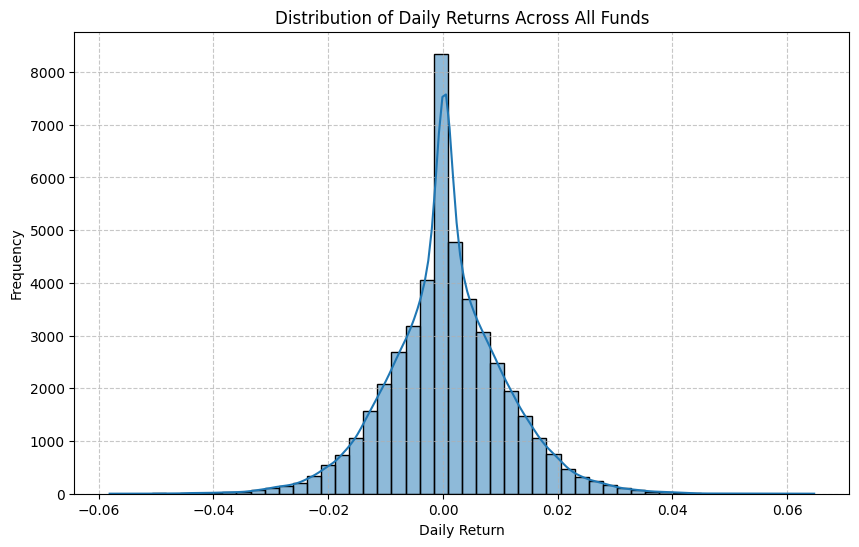


Descriptive statistics for cleaned daily returns:


,daily_return
count,45960.000000
mean,0.000631
std,0.010290
min,-0.058102
25%,-0.005042
50%,0.000340
75%,0.006324
max,0.064713


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Remove NaN values from daily_return (first return for each fund is NaN)
daily_returns_cleaned = nav_history_df['daily_return'].dropna()

plt.figure(figsize=(10, 6))
sns.histplot(daily_returns_cleaned, bins=50, kde=True)
plt.title('Distribution of Daily Returns Across All Funds')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

print("\nDescriptive statistics for cleaned daily returns:")
display(daily_returns_cleaned.describe())

### Compound Annual Growth Rate (CAGR) Calculation

I will calculate the CAGR for 1-year, 3-year, and 5-year periods for all funds. First, I'll merge the `fund_master_df` with `nav_history_df` to get comprehensive fund information, including the launch date. Then, I'll define a helper function to calculate CAGR considering the available data for each fund.

In [4]:
# Merge fund_master_df and nav_history_df on 'amfi_code'
# This is necessary to get fund details like scheme_name and launch_date for each NAV record
merged_df = pd.merge(nav_history_df, fund_master_df[['amfi_code', 'scheme_name', 'launch_date']], on='amfi_code', how='left')

# Convert launch_date to datetime
merged_df['launch_date'] = pd.to_datetime(merged_df['launch_date'])

print("Merged DataFrame with fund details and NAV history (first 5 rows):")
display(merged_df.head())

# Display some info on the merged_df to ensure data types are correct
print("\nInfo on Merged DataFrame:")
merged_df.info()

Merged DataFrame with fund details and NAV history (first 5 rows):


,amfi_code,date,nav,daily_return,scheme_name,launch_date
0,100016,2022-01-03,520.4608,NaN,HDFC Top 100 Fund - Regular Plan - Growth,1996-09-11
1,100016,2022-01-04,515.0971,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth,1996-09-11
2,100016,2022-01-05,521.7239,0.012865,HDFC Top 100 Fund - Regular Plan - Growth,1996-09-11
3,100016,2022-01-06,515.7880,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth,1996-09-11
4,100016,2022-01-07,515.1639,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth,1996-09-11



Info on Merged DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   amfi_code     46000 non-null  int64         
 1   date          46000 non-null  datetime64[ns]
 2   nav           46000 non-null  float64       
 3   daily_return  45960 non-null  float64       
 4   scheme_name   46000 non-null  object        
 5   launch_date   46000 non-null  datetime64[ns]
dtypes: datetime64[ns](2), float64(2), int64(1), object(1)
memory usage: 2.1+ MB


In [5]:
from datetime import timedelta

def calculate_cagr(df_fund, years):
    """
    Calculates the Compound Annual Growth Rate (CAGR) for a given fund over a specified number of years.
    Assumes df_fund is sorted by date.
    """
    if df_fund.empty:
        return None

    # Get the latest date available for the fund
    end_date = df_fund['date'].max()

    # Calculate the start date for the period
    start_date = end_date - timedelta(days=years * 365)

    # Filter data for the period
    period_df = df_fund[(df_fund['date'] >= start_date) & (df_fund['date'] <= end_date)]

    if period_df.empty or len(period_df) < 2:
        return None # Not enough data for the period

    nav_start = period_df.iloc[0]['nav']
    nav_end = period_df.iloc[-1]['nav']

    # Ensure nav_start is not zero to avoid division by zero
    if nav_start == 0:
        return None

    # Calculate actual number of years based on available data
    actual_years = (period_df.iloc[-1]['date'] - period_df.iloc[0]['date']).days / 365.25

    if actual_years <= 0:
        return None

    cagr = (nav_end / nav_start)**(1 / actual_years) - 1
    return cagr

# Initialize a dictionary to store CAGR results
cagr_results = {
    'amfi_code': [],
    'scheme_name': [],
    'cagr_1yr': [],
    'cagr_3yr': [],
    'cagr_5yr': []
}

# Group by amfi_code and calculate CAGR for each fund
for amfi_code, group in merged_df.groupby('amfi_code'):
    scheme_name = group['scheme_name'].iloc[0]

    cagr_results['amfi_code'].append(amfi_code)
    cagr_results['scheme_name'].append(scheme_name)
    cagr_results['cagr_1yr'].append(calculate_cagr(group, 1))
    cagr_results['cagr_3yr'].append(calculate_cagr(group, 3))
    cagr_results['cagr_5yr'].append(calculate_cagr(group, 5))

cagr_df = pd.DataFrame(cagr_results)

print("CAGR Comparison Table:")
display(cagr_df.head())

print("\nDescriptive statistics for CAGR values:")
display(cagr_df.describe())

CAGR Comparison Table:


,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.022258,0.010314,0.026371
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.037076,0.039052,0.044582
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532772,0.324724,0.301232
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.479638,0.286914,0.235384
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.240003,-0.046968,0.079388



Descriptive statistics for CAGR values:


,amfi_code,cagr_1yr,cagr_3yr,cagr_5yr
count,40.000000,40.000000,40.000000,40.000000
mean,120247.000000,0.194445,0.162935,0.167357
std,14534.998667,0.229306,0.121714,0.103090
min,100016.000000,-0.428195,-0.109465,0.011717
25%,118632.750000,0.073832,0.066104,0.068618
50%,119551.500000,0.174871,0.179143,0.166073
75%,120842.250000,0.271826,0.269135,0.244883
max,149324.000000,0.828516,0.353624,0.328274


### Sharpe Ratio Calculation

Now, I will compute the Sharpe Ratio for each fund using the formula: $(Rp - Rf) / Std(Rp) \times \sqrt{252}$. I will use a risk-free rate (Rf) of 6.5% and convert it to a daily rate. Funds will then be ranked based on their Sharpe Ratios.

In [6]:
# Define the annual risk-free rate (Rf) as 6.5%
annual_risk_free_rate = 0.065

# Convert to daily risk-free rate
# Assuming 252 trading days in a year
daily_risk_free_rate = (1 + annual_risk_free_rate)**(1/252) - 1

# Initialize lists to store Sharpe Ratio results
sharpe_results = {
    'amfi_code': [],
    'scheme_name': [],
    'sharpe_ratio': []
}

# Group by amfi_code to calculate Sharpe Ratio for each fund
for amfi_code, group in merged_df.groupby('amfi_code'):
    scheme_name = group['scheme_name'].iloc[0]

    # Filter out NaN daily returns for calculations
    fund_returns = group['daily_return'].dropna()

    if len(fund_returns) < 2: # Need at least 2 returns to calculate std dev
        sharpe_results['amfi_code'].append(amfi_code)
        sharpe_results['scheme_name'].append(scheme_name)
        sharpe_results['sharpe_ratio'].append(None)
        continue

    avg_daily_return = fund_returns.mean()
    std_daily_return = fund_returns.std()

    # Calculate excess daily return
    excess_daily_return = avg_daily_return - daily_risk_free_rate

    # Calculate Sharpe Ratio
    # Handle case where standard deviation is zero to avoid division by zero
    if std_daily_return == 0:
        sharpe_ratio = None # Or np.inf if preferred, but None for consistency
    else:
        sharpe_ratio = (excess_daily_return / std_daily_return) * (252**0.5)

    sharpe_results['amfi_code'].append(amfi_code)
    sharpe_results['scheme_name'].append(scheme_name)
    sharpe_results['sharpe_ratio'].append(sharpe_ratio)

sharpe_df = pd.DataFrame(sharpe_results)

# Rank funds by Sharpe Ratio (higher is better)
sharpe_df = sharpe_df.sort_values(by='sharpe_ratio', ascending=False).reset_index(drop=True)
sharpe_df['sharpe_rank'] = sharpe_df['sharpe_ratio'].rank(ascending=False, method='min')

print("Sharpe Ratio and Rank Comparison Table:")
display(sharpe_df.head())

print("\nDescriptive statistics for Sharpe Ratios:")
display(sharpe_df.describe())

Sharpe Ratio and Rank Comparison Table:


,amfi_code,scheme_name,sharpe_ratio,sharpe_rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,1.462504,1.0
1,120843,Kotak Flexicap Fund - Regular - Growth,1.319442,2.0
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,1.246344,3.0
3,119551,SBI Bluechip Fund - Regular Plan - Growth,1.222947,4.0
4,120505,ICICI Pru Midcap Fund - Regular - Growth,1.190559,5.0



Descriptive statistics for Sharpe Ratios:


,amfi_code,sharpe_ratio,sharpe_rank
count,40.000000,40.000000,40.000000
mean,120247.000000,0.581513,20.500000
std,14534.998667,0.542977,11.690452
min,100016.000000,-0.515438,1.000000
25%,118632.750000,0.129849,10.750000
50%,119551.500000,0.671260,20.500000
75%,120842.250000,1.016612,30.250000
max,149324.000000,1.462504,40.000000


### Sortino Ratio Calculation

Next, I will compute the Sortino Ratio. Similar to the Sharpe Ratio, but the Sortino Ratio only considers downside deviation (standard deviation of negative returns), providing a better measure of risk for investors concerned about losses. I will use the same risk-free rate of 6.5%.

In [7]:
import numpy as np

# Initialize lists to store Sortino Ratio results
sortino_results = {
    'amfi_code': [],
    'scheme_name': [],
    'sortino_ratio': []
}

# Group by amfi_code to calculate Sortino Ratio for each fund
for amfi_code, group in merged_df.groupby('amfi_code'):
    scheme_name = group['scheme_name'].iloc[0]

    # Filter out NaN daily returns and consider only negative returns for downside deviation
    fund_returns = group['daily_return'].dropna()

    if len(fund_returns) < 2:
        sortino_results['amfi_code'].append(amfi_code)
        sortino_results['scheme_name'].append(scheme_name)
        sortino_results['sortino_ratio'].append(None)
        continue

    avg_daily_return = fund_returns.mean()

    # Calculate downside deviation: standard deviation of only negative returns
    downside_returns = fund_returns[fund_returns < 0]
    if len(downside_returns) < 2: # Need at least 2 negative returns to calculate std dev meaningfully
        std_downside_return = 0
    else:
        std_downside_return = downside_returns.std()

    # Calculate excess daily return
    excess_daily_return = avg_daily_return - daily_risk_free_rate

    # Calculate Sortino Ratio
    # Handle case where standard deviation of downside returns is zero
    if std_downside_return == 0:
        sortino_ratio = None
    else:
        sortino_ratio = (excess_daily_return / std_downside_return) * (252**0.5)

    sortino_results['amfi_code'].append(amfi_code)
    sortino_results['scheme_name'].append(scheme_name)
    sortino_results['sortino_ratio'].append(sortino_ratio)

sortino_df = pd.DataFrame(sortino_results)

# Rank funds by Sortino Ratio (higher is better)
sortino_df = sortino_df.sort_values(by='sortino_ratio', ascending=False).reset_index(drop=True)
sortino_df['sortino_rank'] = sortino_df['sortino_ratio'].rank(ascending=False, method='min')

print("Sortino Ratio and Rank Comparison Table:")
display(sortino_df.head())

print("\nDescriptive statistics for Sortino Ratios:")
display(sortino_df.describe())

Sortino Ratio and Rank Comparison Table:


,amfi_code,scheme_name,sortino_ratio,sortino_rank
0,148567,Mirae Asset Large Cap Fund - Regular - Growth,2.409056,1.0
1,120843,Kotak Flexicap Fund - Regular - Growth,2.387295,2.0
2,148569,Mirae Asset Tax Saver Fund - Regular - Growth,2.166757,3.0
3,119551,SBI Bluechip Fund - Regular Plan - Growth,2.166272,4.0
4,120505,ICICI Pru Midcap Fund - Regular - Growth,2.047336,5.0



Descriptive statistics for Sortino Ratios:


,amfi_code,sortino_ratio,sortino_rank
count,40.000000,40.000000,40.000000
mean,120247.000000,1.010714,20.500000
std,14534.998667,0.946934,11.690452
min,100016.000000,-0.859988,1.000000
25%,118632.750000,0.220069,10.750000
50%,119551.500000,1.172418,20.500000
75%,120842.250000,1.825365,30.250000
max,149324.000000,2.409056,40.000000


### Alpha and Beta Calculation

To calculate Alpha and Beta for each fund, I'll first load the `09_benchmark_indices.csv` data, which contains Nifty 100 returns. Then, I will perform an OLS regression of each fund's daily returns against the Nifty 100 daily returns using `scipy.stats.linregress`. Alpha will be annualized by multiplying the intercept by 252.

In [10]:
from scipy.stats import linregress

# Load benchmark indices data
benchmark_url = 'https://github.com/neeraj-ch7/bluestock_mf_capstone/blob/main/data/raw/10_benchmark_indices.csv?raw=true'
benchmark_df = pd.read_csv(benchmark_url)

# Convert 'date' column to datetime
benchmark_df['date'] = pd.to_datetime(benchmark_df['date'])

# Sort by date
benchmark_df = benchmark_df.sort_values(by='date')

# Filter for NIFTY100 and calculate daily returns
nifty100_df = benchmark_df[benchmark_df['index_name'] == 'NIFTY100'].copy()
nifty100_df = nifty100_df.sort_values(by='date') # Ensure it's sorted by date
nifty100_df['nifty100_daily_return'] = nifty100_df['close_value'].pct_change()

print("Nifty 100 Benchmark Data (first 5 rows):")
display(nifty100_df.head())

# Prepare merged_df for regression: ensure dates align with benchmark
# Filter merged_df to include only dates present in benchmark_df
# And ensure there are no NaNs in daily_return

# Merge fund returns with benchmark returns
alignment_df = pd.merge(
    merged_df[['amfi_code', 'date', 'daily_return', 'scheme_name']],
    nifty100_df[['date', 'nifty100_daily_return']], # Use the filtered Nifty100 data
    on='date',
    how='inner'
)

# Drop rows where either fund_daily_return or nifty100_daily_return is NaN
alignment_df = alignment_df.dropna(subset=['daily_return', 'nifty100_daily_return'])

print("\nAlignment DataFrame for regression (first 5 rows):")
display(alignment_df.head())

# Initialize lists to store Alpha and Beta results
alpha_beta_results = {
    'amfi_code': [],
    'scheme_name': [],
    'alpha': [],
    'beta': []
}

# Group by amfi_code and perform OLS regression
for amfi_code, group in alignment_df.groupby('amfi_code'):
    scheme_name = group['scheme_name'].iloc[0]

    # Ensure enough data points for meaningful regression
    if len(group) < 2:
        alpha_beta_results['amfi_code'].append(amfi_code)
        alpha_beta_results['scheme_name'].append(scheme_name)
        alpha_beta_results['alpha'].append(None)
        alpha_beta_results['beta'].append(None)
        continue

    # Perform linear regression
    # Ensure there's enough variance in the independent variable
    if group['nifty100_daily_return'].std() == 0:
        alpha_beta_results['amfi_code'].append(amfi_code)
        alpha_beta_results['scheme_name'].append(scheme_name)
        alpha_beta_results['alpha'].append(None)
        alpha_beta_results['beta'].append(None)
        continue

    slope, intercept, r_value, p_value, std_err = linregress(
        group['nifty100_daily_return'], group['daily_return']
    )

    # Annualize Alpha (intercept) by multiplying by 252 trading days
    annualized_alpha = intercept * 252

    alpha_beta_results['amfi_code'].append(amfi_code)
    alpha_beta_results['scheme_name'].append(scheme_name)
    alpha_beta_results['alpha'].append(annualized_alpha)
    alpha_beta_results['beta'].append(slope)

alpha_beta_df = pd.DataFrame(alpha_beta_results)

# Rank funds by Alpha (higher is better)
alpha_beta_df = alpha_beta_df.sort_values(by='alpha', ascending=False).reset_index(drop=True)
alpha_beta_df['alpha_rank'] = alpha_beta_df['alpha'].rank(ascending=False, method='min')

print("\nAlpha and Beta Comparison Table (ranked by Alpha):")
display(alpha_beta_df.head())

print("\nDescriptive statistics for Alpha and Beta:")
display(alpha_beta_df.describe())

Nifty 100 Benchmark Data (first 5 rows):


,date,index_name,close_value,nifty100_daily_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150



Alignment DataFrame for regression (first 5 rows):


,amfi_code,date,daily_return,scheme_name,nifty100_daily_return
1,100016,2022-01-04,-0.010306,HDFC Top 100 Fund - Regular Plan - Growth,-0.013540
2,100016,2022-01-05,0.012865,HDFC Top 100 Fund - Regular Plan - Growth,0.004003
3,100016,2022-01-06,-0.011377,HDFC Top 100 Fund - Regular Plan - Growth,-0.002935
4,100016,2022-01-07,-0.001210,HDFC Top 100 Fund - Regular Plan - Growth,0.006150
5,100016,2022-01-10,-0.008639,HDFC Top 100 Fund - Regular Plan - Growth,-0.008351



Alpha and Beta Comparison Table (ranked by Alpha):


,amfi_code,scheme_name,alpha,beta,alpha_rank
0,119598,SBI Small Cap Fund - Regular Plan - Growth,0.303370,-0.023196,1.0
1,149324,DSP Small Cap Fund - Regular - Growth,0.300579,0.011455,2.0
2,120505,ICICI Pru Midcap Fund - Regular - Growth,0.292636,0.000549,3.0
3,148569,Mirae Asset Tax Saver Fund - Regular - Growth,0.282704,0.018134,4.0
4,120843,Kotak Flexicap Fund - Regular - Growth,0.273305,-0.022830,5.0



Descriptive statistics for Alpha and Beta:


,amfi_code,alpha,beta,alpha_rank
count,40.000000,40.000000,40.000000,40.000000
mean,120247.000000,0.159085,-0.001958,20.500000
std,14534.998667,0.087528,0.035194,11.690452
min,100016.000000,0.028969,-0.066951,1.000000
25%,118632.750000,0.068612,-0.023937,10.750000
50%,119551.500000,0.162326,-0.000067,20.500000
75%,120842.250000,0.221723,0.017026,30.250000
max,149324.000000,0.303370,0.103497,40.000000


### Deliverables: Exporting Results

In [11]:
# Export alpha_beta_df to CSV
alpha_beta_df.to_csv('alpha_beta.csv', index=False)
print("alpha_beta.csv has been created successfully.")

alpha_beta.csv has been created successfully.


### Create Fund Scorecard

In [12]:
# Merge all performance metrics into a single DataFrame for the Fund Scorecard
fund_scorecard_df = cagr_df.merge(sharpe_df[['amfi_code', 'sharpe_ratio', 'sharpe_rank']], on='amfi_code', how='left')
fund_scorecard_df = fund_scorecard_df.merge(sortino_df[['amfi_code', 'sortino_ratio', 'sortino_rank']], on='amfi_code', how='left')
fund_scorecard_df = fund_scorecard_df.merge(alpha_beta_df[['amfi_code', 'alpha', 'beta', 'alpha_rank']], on='amfi_code', how='left')

print("Fund Scorecard (first 5 rows):")
display(fund_scorecard_df.head())

# Export fund_scorecard_df to CSV
fund_scorecard_df.to_csv('fund_scorecard.csv', index=False)
print("fund_scorecard.csv has been created successfully.")

Fund Scorecard (first 5 rows):


,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,sharpe_rank,sortino_ratio,sortino_rank,alpha,beta,alpha_rank
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.022258,0.010314,0.026371,-0.187650,36.0,-0.326892,36.0,0.037476,-0.058268,39.0
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.037076,0.039052,0.044582,-0.515438,40.0,-0.856030,39.0,0.042818,0.001158,38.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532772,0.324724,0.301232,1.104352,7.0,1.846950,9.0,0.271954,0.005104,6.0
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.479638,0.286914,0.235384,1.041061,9.0,1.823822,11.0,0.213998,0.021086,12.0
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.240003,-0.046968,0.079388,0.170481,29.0,0.289943,29.0,0.108971,-0.065289,27.0


fund_scorecard.csv has been created successfully.


### Maximum Drawdown (MDD) Calculation

In [13]:
def calculate_max_drawdown(nav_series):
    """
    Calculates the Maximum Drawdown (MDD) for a given NAV series.
    """
    if nav_series.empty or len(nav_series) < 2:
        return None

    # Calculate the running maximum NAV
    running_max = nav_series.expanding().max()

    # Calculate drawdown from the running maximum
    drawdown = (nav_series / running_max) - 1

    # Maximum Drawdown is the minimum (most negative) drawdown
    mdd = drawdown.min()
    return mdd

# Initialize lists to store Maximum Drawdown results
mdd_results = {
    'amfi_code': [],
    'scheme_name': [],
    'max_drawdown': []
}

# Group by amfi_code and calculate MDD for each fund
for amfi_code, group in merged_df.groupby('amfi_code'):
    scheme_name = group['scheme_name'].iloc[0]
    fund_nav_series = group.sort_values(by='date')['nav'] # Ensure NAV series is sorted by date

    mdd = calculate_max_drawdown(fund_nav_series)

    mdd_results['amfi_code'].append(amfi_code)
    mdd_results['scheme_name'].append(scheme_name)
    mdd_results['max_drawdown'].append(mdd)

mdd_df = pd.DataFrame(mdd_results)

# Rank funds by Max Drawdown (lower absolute value is better, so ascending=False to rank smaller negative numbers higher)
mdd_df = mdd_df.sort_values(by='max_drawdown', ascending=False).reset_index(drop=True)
mdd_df['mdd_rank'] = mdd_df['max_drawdown'].rank(ascending=False, method='min')

print("Maximum Drawdown Comparison Table (ranked by MDD):")
display(mdd_df.head())

print("\nDescriptive statistics for Maximum Drawdown:")
display(mdd_df.describe())

# Optionally, add MDD to the fund_scorecard_df
fund_scorecard_df = fund_scorecard_df.merge(mdd_df[['amfi_code', 'max_drawdown', 'mdd_rank']], on='amfi_code', how='left')
print("\nFund Scorecard with Maximum Drawdown (first 5 rows):")
display(fund_scorecard_df.head())

# Re-export the updated fund_scorecard_df
fund_scorecard_df.to_csv('fund_scorecard.csv', index=False)
print("fund_scorecard.csv has been updated with Maximum Drawdown successfully.")

Maximum Drawdown Comparison Table (ranked by MDD):


,amfi_code,scheme_name,max_drawdown,mdd_rank
0,120507,ICICI Pru Liquid Fund - Regular - Growth,-0.000977,1.0
1,120844,Kotak Liquid Fund - Regular - Growth,-0.001163,2.0
2,101208,ABSL Liquid Fund - Regular - Growth,-0.001622,3.0
3,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.043083,4.0
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.043287,5.0



Descriptive statistics for Maximum Drawdown:


,amfi_code,max_drawdown,mdd_rank
count,40.000000,40.000000,40.000000
mean,120247.000000,-0.178729,20.500000
std,14534.998667,0.112686,11.690452
min,100016.000000,-0.525742,1.000000
25%,118632.750000,-0.215927,10.750000
50%,119551.500000,-0.163070,20.500000
75%,120842.250000,-0.117653,30.250000
max,149324.000000,-0.000977,40.000000



Fund Scorecard with Maximum Drawdown (first 5 rows):


,amfi_code,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr,sharpe_ratio,sharpe_rank,sortino_ratio,sortino_rank,alpha,beta,alpha_rank,max_drawdown,mdd_rank
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.022258,0.010314,0.026371,-0.187650,36.0,-0.326892,36.0,0.037476,-0.058268,39.0,-0.247344,34.0
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.037076,0.039052,0.044582,-0.515438,40.0,-0.856030,39.0,0.042818,0.001158,38.0,-0.043083,4.0
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.532772,0.324724,0.301232,1.104352,7.0,1.846950,9.0,0.271954,0.005104,6.0,-0.162172,20.0
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.479638,0.286914,0.235384,1.041061,9.0,1.823822,11.0,0.213998,0.021086,12.0,-0.112916,9.0
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.240003,-0.046968,0.079388,0.170481,29.0,0.289943,29.0,0.108971,-0.065289,27.0,-0.354469,38.0


fund_scorecard.csv has been updated with Maximum Drawdown successfully.
